# Evaluation

In this section, SHAP values are calculated and high-fork low-conversion repositories are identified.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesClassifier,
    ExtraTreesRegressor,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    precision_score,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
%matplotlib inline

In [2]:
!pip install shap

## Load Data

From the data preparation stage, the main dataset of 30 days observation window is loaded:

In [183]:
DATA_DIRS = [Path("data"), Path("src/data"), Path("../src/data")]
MAIN_OBSERVATION_WINDOW_DAYS = 30
SENSITIVITY_WINDOWS_DAYS = (30, 90)


def _looks_like_git_lfs_pointer(path: Path) -> bool:
    """Detect tiny text pointer files committed by Git LFS instead of real binary data."""
    try:
        head = path.read_bytes()[:64]
    except Exception:
        return False
    return head.startswith(b"version https://git-lfs.github.com/spec/v1")


def _candidate_paths(basename):
    candidates = []
    for d in DATA_DIRS:
        candidates.append(d / f"{basename}.parquet")
        candidates.append(d / f"{basename}.csv")
    return candidates


def load_dataset(basename):
    load_errors = []
    for p in _candidate_paths(basename):
        if not p.exists():
            continue
        try:
            if p.suffix == ".parquet":
                if _looks_like_git_lfs_pointer(p):
                    raise RuntimeError("Git LFS pointer file detected, not real parquet data")
                return pd.read_parquet(p), p
            return pd.read_csv(p), p
        except Exception as exc:
            load_errors.append(f"{p}: {exc}")

    err_text = "\n".join(load_errors) if load_errors else "No candidate files found"
    raise RuntimeError(
        f"Could not load {basename}.\n"
        "Reason(s):\n"
        f"{err_text}\n\n"
        "If files are Git LFS pointers, fetch real data with `git lfs pull` "
        "or re-export the datasets from DataPreparation.ipynb."
    )


datasets_by_window = {}
sources_by_window = {}
for window in SENSITIVITY_WINDOWS_DAYS:
    datasets_by_window[window], sources_by_window[window] = load_dataset(f"modeling_dataset_obs{window}d")

# Backward-compatible fallback for older exports.
try:
    df = datasets_by_window[MAIN_OBSERVATION_WINDOW_DAYS].copy()
    source_used = sources_by_window[MAIN_OBSERVATION_WINDOW_DAYS]
except KeyError:
    df, source_used = load_dataset("modeling_dataset")

print(f"Loaded main dataset: {source_used}")
print("Shape:", df.shape)
print("Sensitivity sources:")
for window, path in sources_by_window.items():
    print(f"  {window}d: {path} {datasets_by_window[window].shape}")

df.head(3)

Loaded main dataset: data/modeling_dataset_obs30d.parquet
Shape: (100000, 32)
Sensitivity sources:
  30d: data/modeling_dataset_obs30d.parquet (100000, 32)
  90d: data/modeling_dataset_obs90d.parquet (100000, 32)


,repo_name,repo_id,season,log1p_issue_comments,log1p_issue_comments_winsor,log1p_issues,log1p_issues_winsor,log1p_pushes,log1p_pushes_winsor,log1p_releases,log1p_releases_winsor,log1p_watches,log1p_watches_winsor,activity_strength,stratum_activity_quintile,stratum_fork_quintile,observation_window_days,n_forks,n_converted_forks,fork_conversion_rate,n_pr_events,has_conversion,watches,pushes,issues,issue_comments,releases,watches_winsor,pushes_winsor,issues_winsor,issue_comments_winsor,releases_winsor
0,AutomationPanda/awesome-web-testing-playwright,3002,winter_spring,0.693147,0.693147,0.693147,0.693147,0.000000,0.000000,0.0,0.0,3.178054,3.178054,4.564348,1,1,30,8,0,0.0,0,0,23,0,1,1,0,23.0,0.0,1.0,1.0,0.0
1,Neamar/KISS,16186,summer_autumn,4.143135,4.143135,3.828641,3.828641,3.135494,3.135494,0.0,0.0,4.007333,4.007333,15.114604,4,2,30,10,3,0.3,35,1,54,22,45,62,0,54.0,22.0,45.0,62.0,0.0
2,magnific0/wondershaper,57159,winter_spring,2.302585,2.302585,1.098612,1.098612,0.000000,0.000000,0.0,0.0,3.401197,3.401197,6.802395,2,0,30,6,0,0.0,0,0,29,0,2,9,0,29.0,0.0,2.0,9.0,0.0


In [188]:
ACTIVITY_COUNT_COLS = ["watches", "pushes", "issues", "issue_comments", "releases"]
LABEL_DERIVED_EXCLUSIONS = [
    "observation_window_days",
    "n_forks",
    "n_converted_forks",
    "fork_conversion_rate",
    "n_pr_events",
    "has_conversion",
    "stratum_fork_quintile",
]


def selected_activity_features(frame):
    identifier_features = ["season"]
    log_features = [c for c in frame.columns if c.startswith("log1p_")]
    raw_features = [c for c in ACTIVITY_COUNT_COLS if c in frame.columns]
    winsor_features = [f"{c}_winsor" for c in ACTIVITY_COUNT_COLS if f"{c}_winsor" in frame.columns]
    helper_features = [c for c in ["activity_strength", "stratum_activity_quintile"] if c in frame.columns]

    ordered = identifier_features + helper_features + log_features + raw_features + winsor_features
    return [c for c in dict.fromkeys(ordered) if c not in LABEL_DERIVED_EXCLUSIONS]


def make_xy(frame):
    y_cls_local = frame["has_conversion"].astype(int)
    y_reg_local = frame["fork_conversion_rate"].astype(float)

    candidate_features_local = selected_activity_features(frame)
    missing = [c for c in ["season"] if c not in frame.columns]
    if missing:
        raise ValueError(f"Required selected features are missing: {missing}")

    X_local = frame[candidate_features_local].copy()
    cat_cols_local = [
        c
        for c in X_local.columns
        if pd.api.types.is_object_dtype(X_local[c])
        or pd.api.types.is_string_dtype(X_local[c])
        or pd.api.types.is_categorical_dtype(X_local[c])
        or pd.api.types.is_bool_dtype(X_local[c])
    ]
    num_cols_local = [c for c in X_local.columns if c not in cat_cols_local]
    return X_local, y_cls_local, y_reg_local, candidate_features_local, cat_cols_local, num_cols_local


X, y_cls, y_reg, candidate_features, cat_cols, num_cols = make_xy(df)

print("Feature columns:", len(candidate_features))
print("Selected features:", candidate_features)
print("Categorical:", cat_cols)
print("Numeric count:", len(num_cols))
print("Excluded label-derived columns:", [c for c in LABEL_DERIVED_EXCLUSIONS if c in df.columns])
print("Class balance (has_conversion):")
display(y_cls.value_counts(normalize=True).rename("share"))

Feature columns: 23
Selected features: ['season', 'activity_strength', 'stratum_activity_quintile', 'log1p_issue_comments', 'log1p_issue_comments_winsor', 'log1p_issues', 'log1p_issues_winsor', 'log1p_pushes', 'log1p_pushes_winsor', 'log1p_releases', 'log1p_releases_winsor', 'log1p_watches', 'log1p_watches_winsor', 'watches', 'pushes', 'issues', 'issue_comments', 'releases', 'watches_winsor', 'pushes_winsor', 'issues_winsor', 'issue_comments_winsor', 'releases_winsor']
Categorical: ['season']
Numeric count: 22
Excluded label-derived columns: ['observation_window_days', 'n_forks', 'n_converted_forks', 'fork_conversion_rate', 'n_pr_events', 'has_conversion', 'stratum_fork_quintile']
Class balance (has_conversion):


,share
has_conversion,
0,0.52758
1,0.47242


## Prepare Models

Following the modeling stage, the best models are evaluated (Histogram Gradient Boosting):

In [189]:
X_train, X_test, y_cls_train, y_cls_test, y_reg_train, y_reg_test = train_test_split(
    X, y_cls, y_reg, test_size=0.2, random_state=42, stratify=y_cls
)


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocess(num_cols_local, cat_cols_local):
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_cols_local),
            (
                "cat",
                Pipeline([
                    ("imp", SimpleImputer(strategy="most_frequent")),
                    ("oh", make_one_hot_encoder()),
                ]),
                cat_cols_local,
            ),
        ],
        remainder="drop",
    )


preprocess = make_preprocess(num_cols, cat_cols)

In [190]:
best_cls_model = Pipeline([
    ("prep", preprocess),
    ("model", HistGradientBoostingClassifier(
        learning_rate=0.06,
        max_iter=180,
        max_leaf_nodes=31,
        l2_regularization=0.01,
        random_state=42,
    ))]
)

In [192]:
best_cls_model.fit(X_train, y_cls_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['activity_strength',
                                                   'stratum_activity_quintile',
                                                   'log1p_issue_comments',
                                                   'log1p_issue_comments_winsor',
                                                   'log1p_issues',
                                                   'log1p_issues_winsor',
                                                   'log1p_pushes',
                                                   'log1p_pushes_winsor',
                                                   'log1p_releases',
                                                   'log1p_...
                                                   'releases', 'watches_winsor',
                                                   'pushes_winsor',
                                                   'issues_winsor',
                                                   'issue_comments_winsor',
                                                   'releases_winsor']),
                                                 ('cat',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('oh',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['season'])])),
                ('model',
                 HistGradientBoostingClassifier(l2_regularization=0.01,
                                                learning_rate=0.06,
                                                max_iter=180,
                                                random_state=42))])

In [191]:
best_reg_model = Pipeline([
        ("prep", preprocess),
        ("model", HistGradientBoostingRegressor(
            learning_rate=0.06,
            max_iter=180,
            max_leaf_nodes=31,
            l2_regularization=0.01,
            random_state=42,
        )),
    ]
)

In [193]:
best_reg_model.fit(X_train, y_reg_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['activity_strength',
                                                   'stratum_activity_quintile',
                                                   'log1p_issue_comments',
                                                   'log1p_issue_comments_winsor',
                                                   'log1p_issues',
                                                   'log1p_issues_winsor',
                                                   'log1p_pushes',
                                                   'log1p_pushes_winsor',
                                                   'log1p_releases',
                                                   'log1p_...
                                                   'releases', 'watches_winsor',
                                                   'pushes_winsor',
                                                   'issues_winsor',
                                                   'issue_comments_winsor',
                                                   'releases_winsor']),
                                                 ('cat',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('oh',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['season'])])),
                ('model',
                 HistGradientBoostingRegressor(l2_regularization=0.01,
                                               learning_rate=0.06, max_iter=180,
                                               random_state=42))])

## SHAP Values

SHAP values are analyzed to reveal internal importances in data decision making of both models:
- Waterfall plot reveals importances for individuals from top and bottom of rankings by each model;
- Decision plot summarizes the effects on a general sample.

### Classification

In [194]:
def _as_dense(matrix):
    return matrix.toarray() if hasattr(matrix, "toarray") else np.asarray(matrix)

In [195]:
cls_prep = best_cls_model.named_steps["prep"]
cls_model = best_cls_model.named_steps["model"]

X_train_trans = cls_prep.transform(X_train)
X_train_trans_dense = _as_dense(X_train_trans)
X_test_trans = cls_prep.transform(X_test)
X_test_trans_dense = _as_dense(X_test_trans)

feat_names = cls_prep.get_feature_names_out()

In [196]:
sample_ids = np.random.choice(X_train_trans_dense.shape[0], 100, replace=False)

background = X_train_trans_dense[sample_ids, :]

In [197]:
feature_names = cls_prep.get_feature_names_out()

In [198]:
def f(x):
    return cls_model.predict_proba(x)

explainer = shap.Explainer(f, background, feature_names=feature_names)
shap_values = explainer(background, check_additivity=False)

PermutationExplainer explainer: 101it [00:48,  1.64it/s]


In [199]:
p_test_for_examples = best_cls_model.predict_proba(X_test)[:, 1]
ranked_positions = np.argsort(p_test_for_examples)[::-1]

In [200]:
k_selected = 5

probs_topk = p_test_for_examples[ranked_positions[:k_selected]]
probs_bottomk = p_test_for_examples[ranked_positions[-k_selected:]]

topk = X_test_trans_dense[ranked_positions[:k_selected], :]
bottomk = X_test_trans_dense[ranked_positions[-k_selected:], :]

In [201]:
shap_values_topk = explainer(topk, check_additivity=False)
shap_values_bottomk = explainer(bottomk, check_additivity=False)

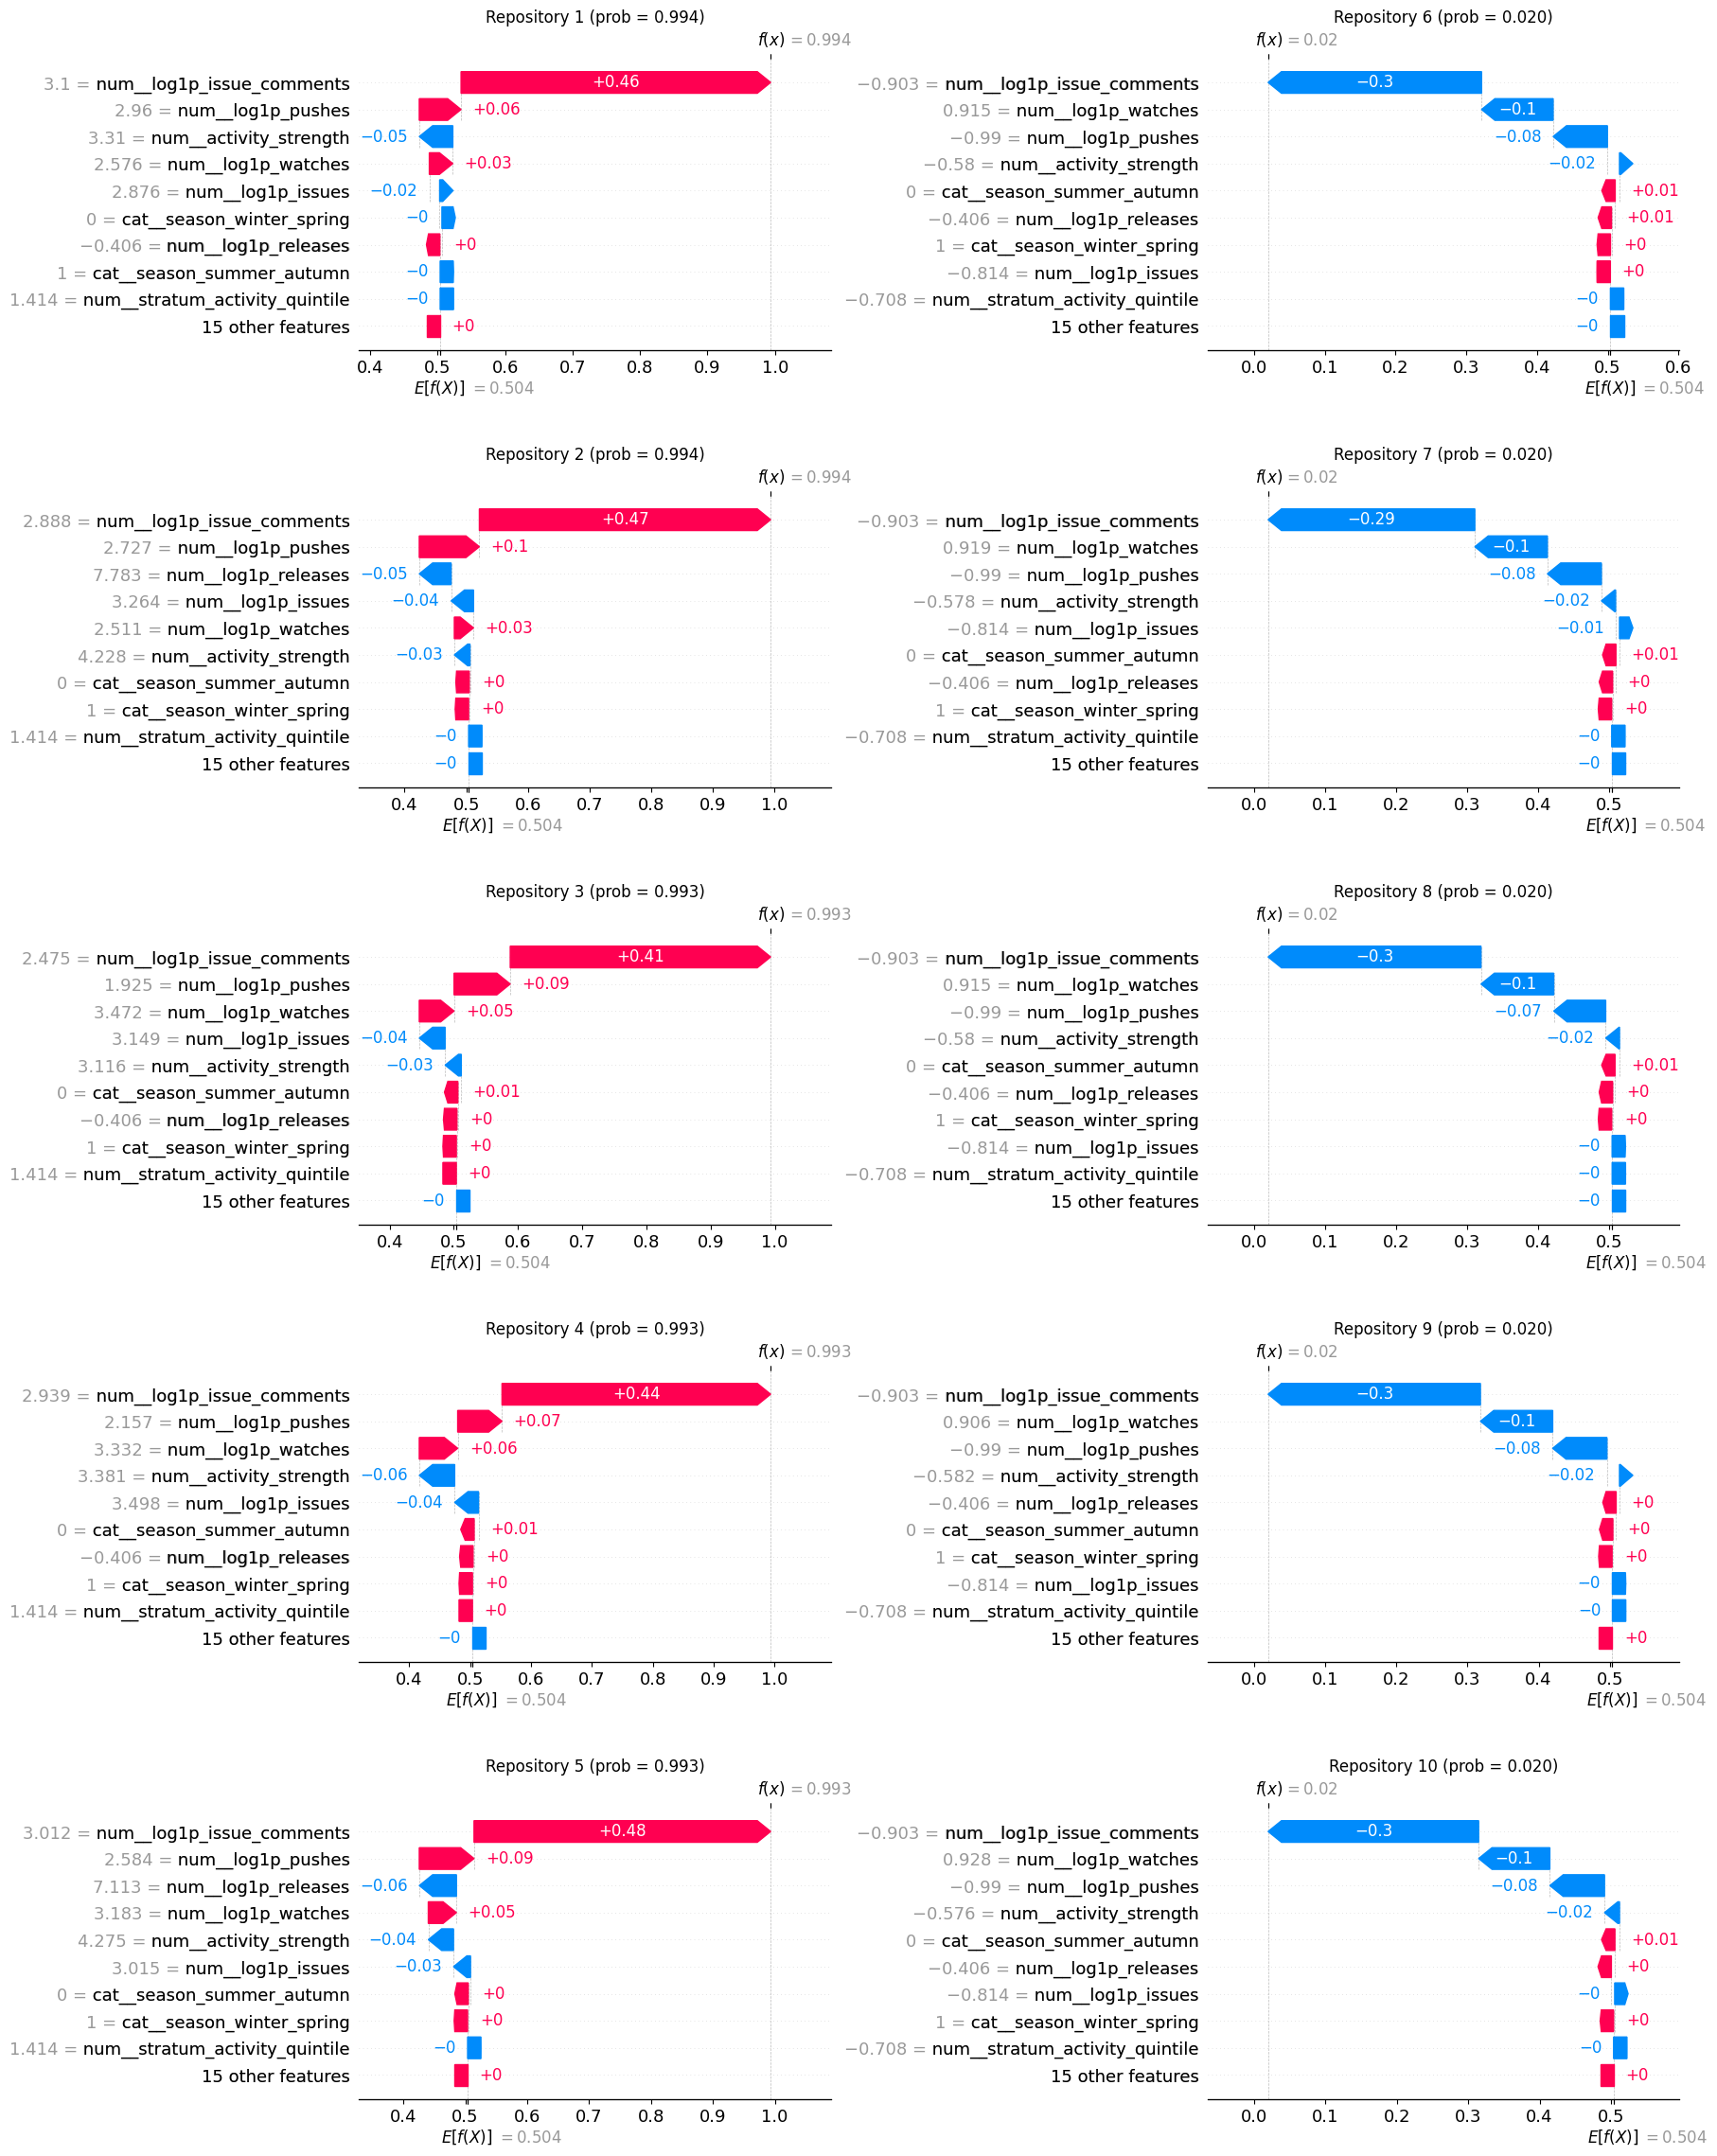

In [202]:
import matplotlib.pyplot as plt
import shap

# Create the grid (figsize will be overridden later)
fig, axes = plt.subplots(5, 2)
axes = axes.T.flatten()

for i, ax in enumerate(axes):
    if i < k_selected:
        exp = shap_values_topk[i, :, 1]          # Explanation for class 1
        prob = probs_topk[i]
    else:
        exp = shap_values_bottomk[i%k_selected, :, 1]          # Explanation for class 1
        prob = probs_bottomk[i%k_selected]
    plt.sca(ax)
    shap.plots.waterfall(exp, show=False)
    ax.set_title(f"Repository {i+1} (prob = {prob:.3f})")


# Adjust overall figure size and spacing
fig.set_size_inches(18, 28)                  # width, height
plt.subplots_adjust(hspace=0.5, wspace=0.8)  # vertical & horizontal gaps
fig.savefig('shap_waterfall_cls.png', dpi=300, bbox_inches='tight')
plt.show()

In [203]:
sample_ids = np.random.choice(X_test_trans_dense.shape[0], 100, replace=False)

background = X_test_trans_dense[sample_ids, :]

In [204]:
def f(x):
    return cls_model.predict_proba(x)

explainer = shap.Explainer(f, background, feature_names=feature_names)
shap_values = explainer(background, check_additivity=False)

PermutationExplainer explainer: 101it [00:46,  1.74it/s]


In [205]:
base_value = shap_values.base_values[0, 1]

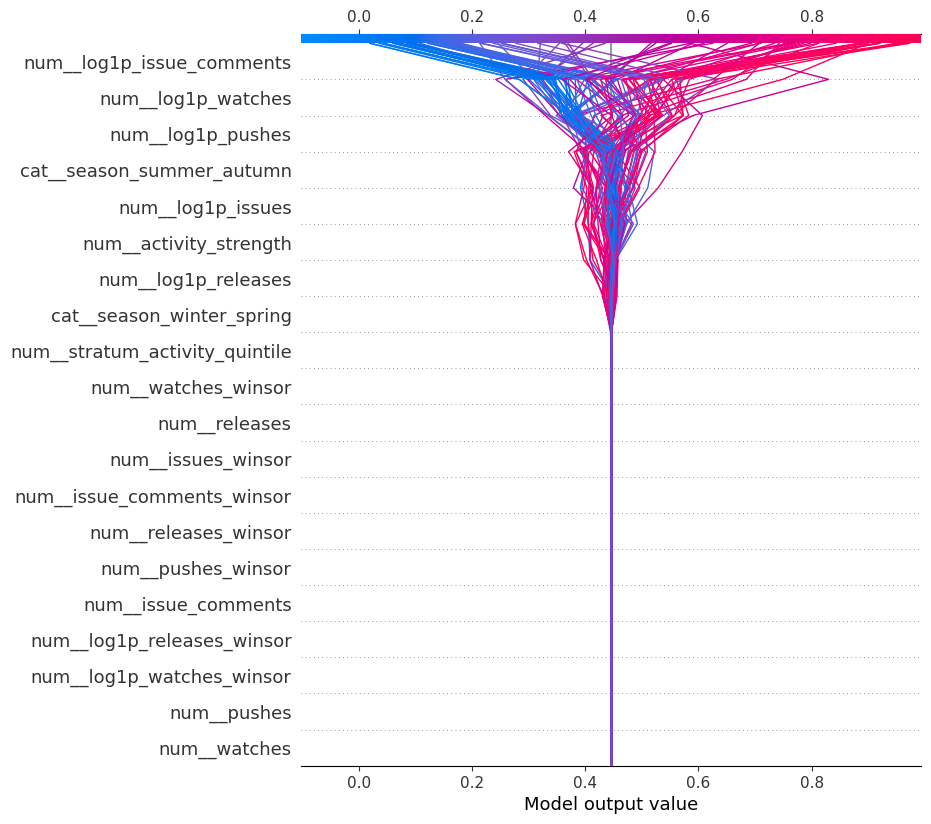

In [206]:
shap.decision_plot(base_value, shap_values.values[:, :, 1], feature_names=feature_names)

### Regression

In [207]:
reg_prep = best_reg_model.named_steps["prep"]
reg_model = best_reg_model.named_steps["model"]

X_train_trans = reg_prep.transform(X_train)
X_train_trans_dense = _as_dense(X_train_trans)
X_test_trans = reg_prep.transform(X_test)
X_test_trans_dense = _as_dense(X_test_trans)

In [208]:
sample_ids = np.random.choice(X_train_trans_dense.shape[0], 100, replace=False)

background = X_train_trans_dense[sample_ids, :]

In [209]:
feature_names = reg_prep.get_feature_names_out()

In [210]:
def g(x):
    return reg_model.predict(x)

explainer = shap.Explainer(g, background, feature_names=feature_names)
shap_values = explainer(background, check_additivity=False)

PermutationExplainer explainer: 101it [00:37,  1.92it/s]


In [211]:
conv_test_for_examples = best_reg_model.predict(X_test)
ranked_positions = np.argsort(conv_test_for_examples)[::-1]

In [212]:
k_selected = 5

convs_topk = conv_test_for_examples[ranked_positions[:k_selected]]
convs_bottomk = conv_test_for_examples[ranked_positions[-k_selected:]]

topk = X_test_trans_dense[ranked_positions[:k_selected], :]
bottomk = X_test_trans_dense[ranked_positions[-k_selected:], :]

In [213]:
shap_values_topk = explainer(topk, check_additivity=False)
shap_values_bottomk = explainer(bottomk, check_additivity=False)

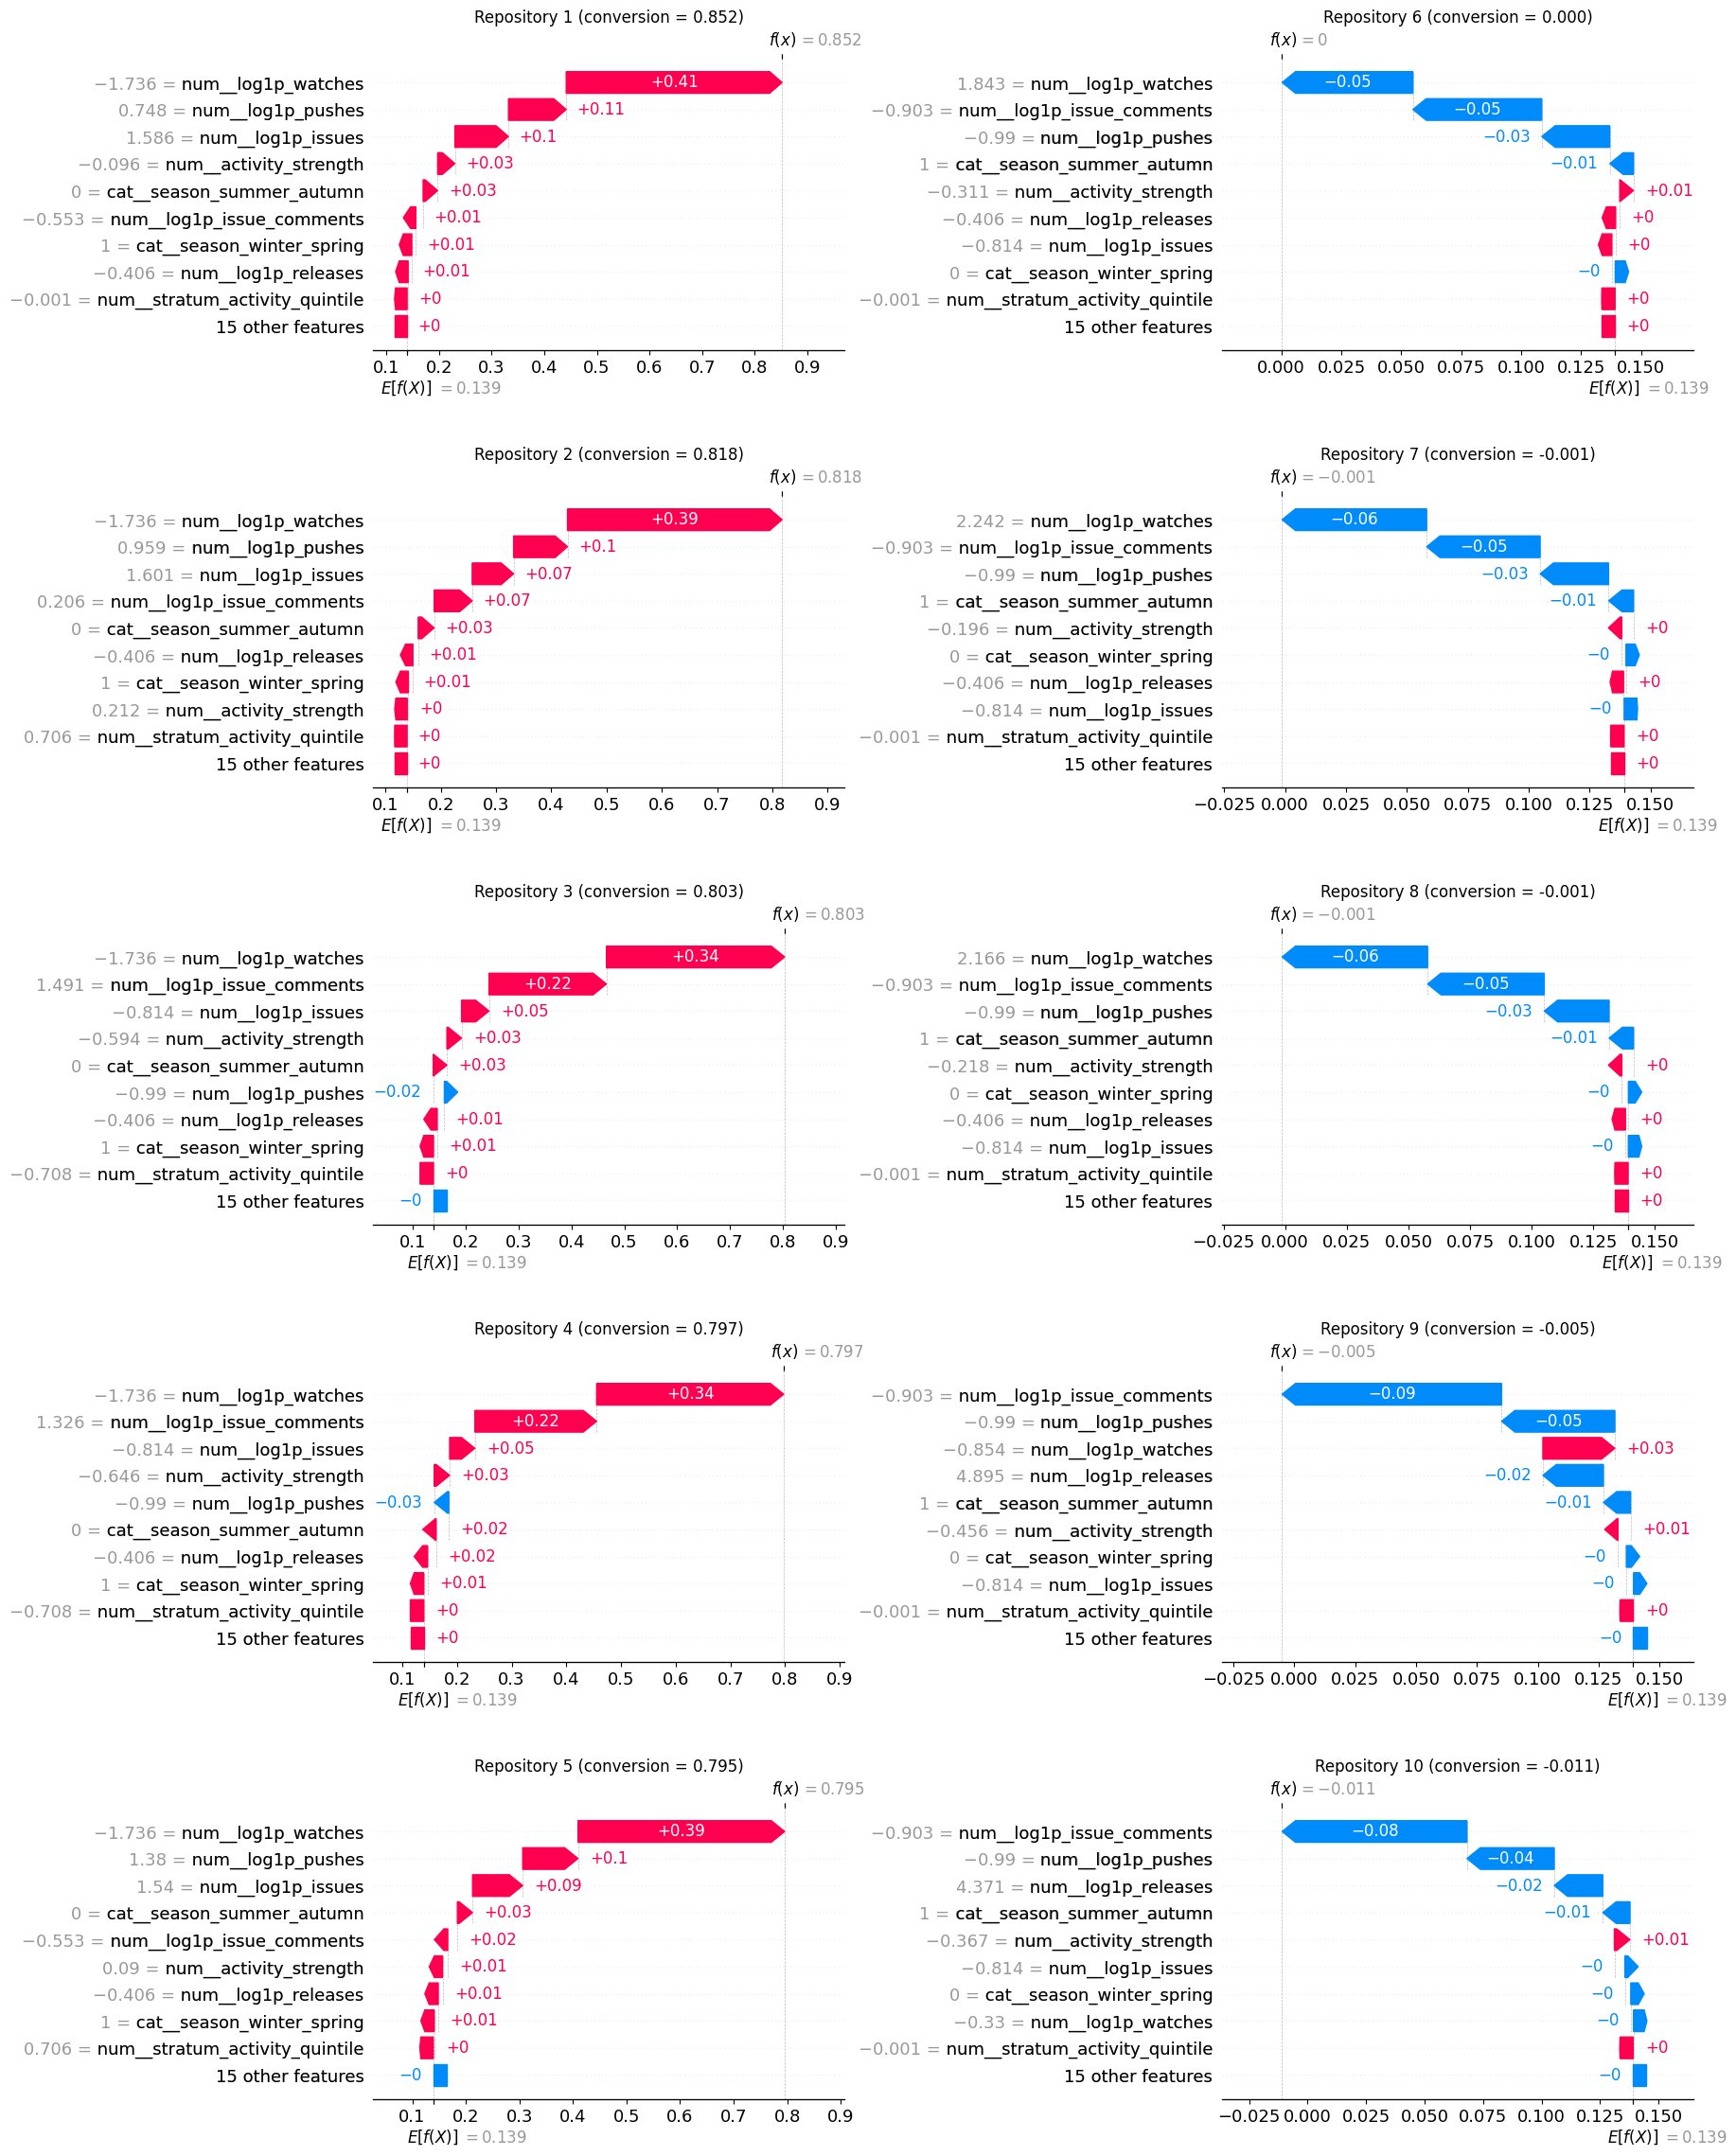

In [214]:
import matplotlib.pyplot as plt
import shap

# Create the grid (figsize will be overridden later)
fig, axes = plt.subplots(5, 2)
axes = axes.T.flatten()

for i, ax in enumerate(axes):
    if i < k_selected:
        exp = shap_values_topk[i, :]          # Explanation for class 1
        conv = convs_topk[i]
    else:
        exp = shap_values_bottomk[i%k_selected, :]          # Explanation for class 1
        conv = convs_bottomk[i%k_selected]
    plt.sca(ax)
    shap.plots.waterfall(exp, show=False)
    ax.set_title(f"Repository {i+1} (conversion = {conv:.3f})")


# Adjust overall figure size and spacing
fig.set_size_inches(18, 28)                  # width, height
plt.subplots_adjust(hspace=0.5, wspace=0.8)  # vertical & horizontal gaps
fig.savefig('shap_waterfall_reg.png', dpi=300, bbox_inches='tight')
plt.show()

In [215]:
sample_ids = np.random.choice(X_test_trans_dense.shape[0], 100, replace=False)

background = X_test_trans_dense[sample_ids, :]

In [216]:
def g(x):
    return reg_model.predict(x)

explainer = shap.Explainer(g, background, feature_names=feature_names)
shap_values = explainer(background, check_additivity=False)

PermutationExplainer explainer: 101it [00:37,  1.96it/s]


In [217]:
base_value = shap_values.base_values[0]

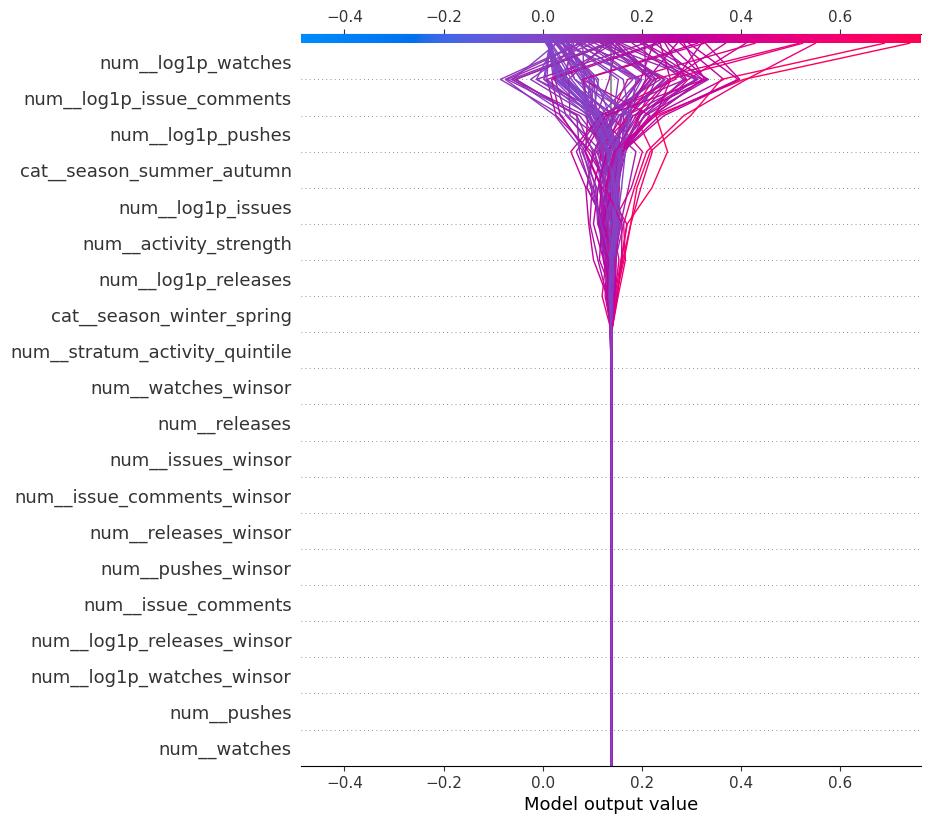

In [218]:
shap.decision_plot(base_value, shap_values.values, feature_names=feature_names)

## Evaluation of High Fork Low Conversion Segment

This stage directly addresses the following business question:
> Are there repository segments where conversion is consistently low despite high fork activity?

**Evaluation procedure**:
1. Define high fork threshold as 75th percentile of forks number.
2. Set the lowest conversion threshold to be the 25th percentile of the fork conversion values.
3. Count repositories that satisfy both scores.

### Load additional labels

In [260]:
y_forks = df['n_forks']
y_prs = df['n_converted_forks']

### Split data

In [261]:
X_train, X_test, y_cls_train, y_cls_test, y_reg_train, y_reg_test, y_forks_train, y_forks_test, y_prs_train, y_prs_test = train_test_split(
    X, y_cls, y_reg, y_forks, y_prs, test_size=0.2, random_state=42, stratify=y_cls
)

### Interpret predictions for test samples of the segment

In [262]:
import numpy as np

# Compute thresholds
high_fork_threshold = np.percentile(y_forks_test, 75)
low_conversion_threshold = np.percentile(y_reg_test, 25)

# Create masks
is_high_fork = y_forks_test >= high_fork_threshold
is_low_conversion = y_reg_test <= low_conversion_threshold

# Segment indices
segment_mask = is_high_fork & is_low_conversion
segment_indices = np.where(segment_mask)[0]  # or use X_test.index[segment_mask] for DataFrame

print(f"High fork threshold: {high_fork_threshold}")
print(f"Low conversion threshold: {low_conversion_threshold}")
print(f"Number of repositories in segment: {len(segment_indices)}")

High fork threshold: 20.0
Low conversion threshold: 0.0
Number of repositories in segment: 1834


In [263]:
cls_prep = best_cls_model.named_steps["prep"]
cls_model = best_cls_model.named_steps["model"]

X_train_trans = cls_prep.transform(X_train)
X_train_trans_dense = _as_dense(X_train_trans)
X_test_trans = cls_prep.transform(X_test)
X_test_trans_dense = _as_dense(X_test_trans)

feature_names = cls_prep.get_feature_names_out()

In [264]:
sample_ids = np.random.choice(X_test_trans_dense.shape[0], 100, replace=False)

background = X_test_trans_dense[sample_ids, :]

In [265]:
feature_names = cls_prep.get_feature_names_out()

In [266]:
def f(x):
    return cls_model.predict_proba(x)

explainer = shap.Explainer(f, background, feature_names=feature_names)
shap_values = explainer(background, check_additivity=False)

PermutationExplainer explainer: 101it [00:53,  1.51it/s]


In [267]:
sample_ids = np.random.choice(segment_indices.shape[0], 10, replace=False)

X_segment = X_test.iloc[segment_indices[sample_ids]]
X_segment_trans = X_test_trans_dense[segment_indices[sample_ids], :]

In [268]:
shap_values_segment = explainer(X_segment_trans, check_additivity=False)

In [269]:
probs = best_cls_model.predict_proba(X_segment)[:, -1]
forks = y_forks_test.iloc[segment_indices[sample_ids]].to_numpy()
convs = y_cls_test.iloc[segment_indices[sample_ids]].to_numpy()

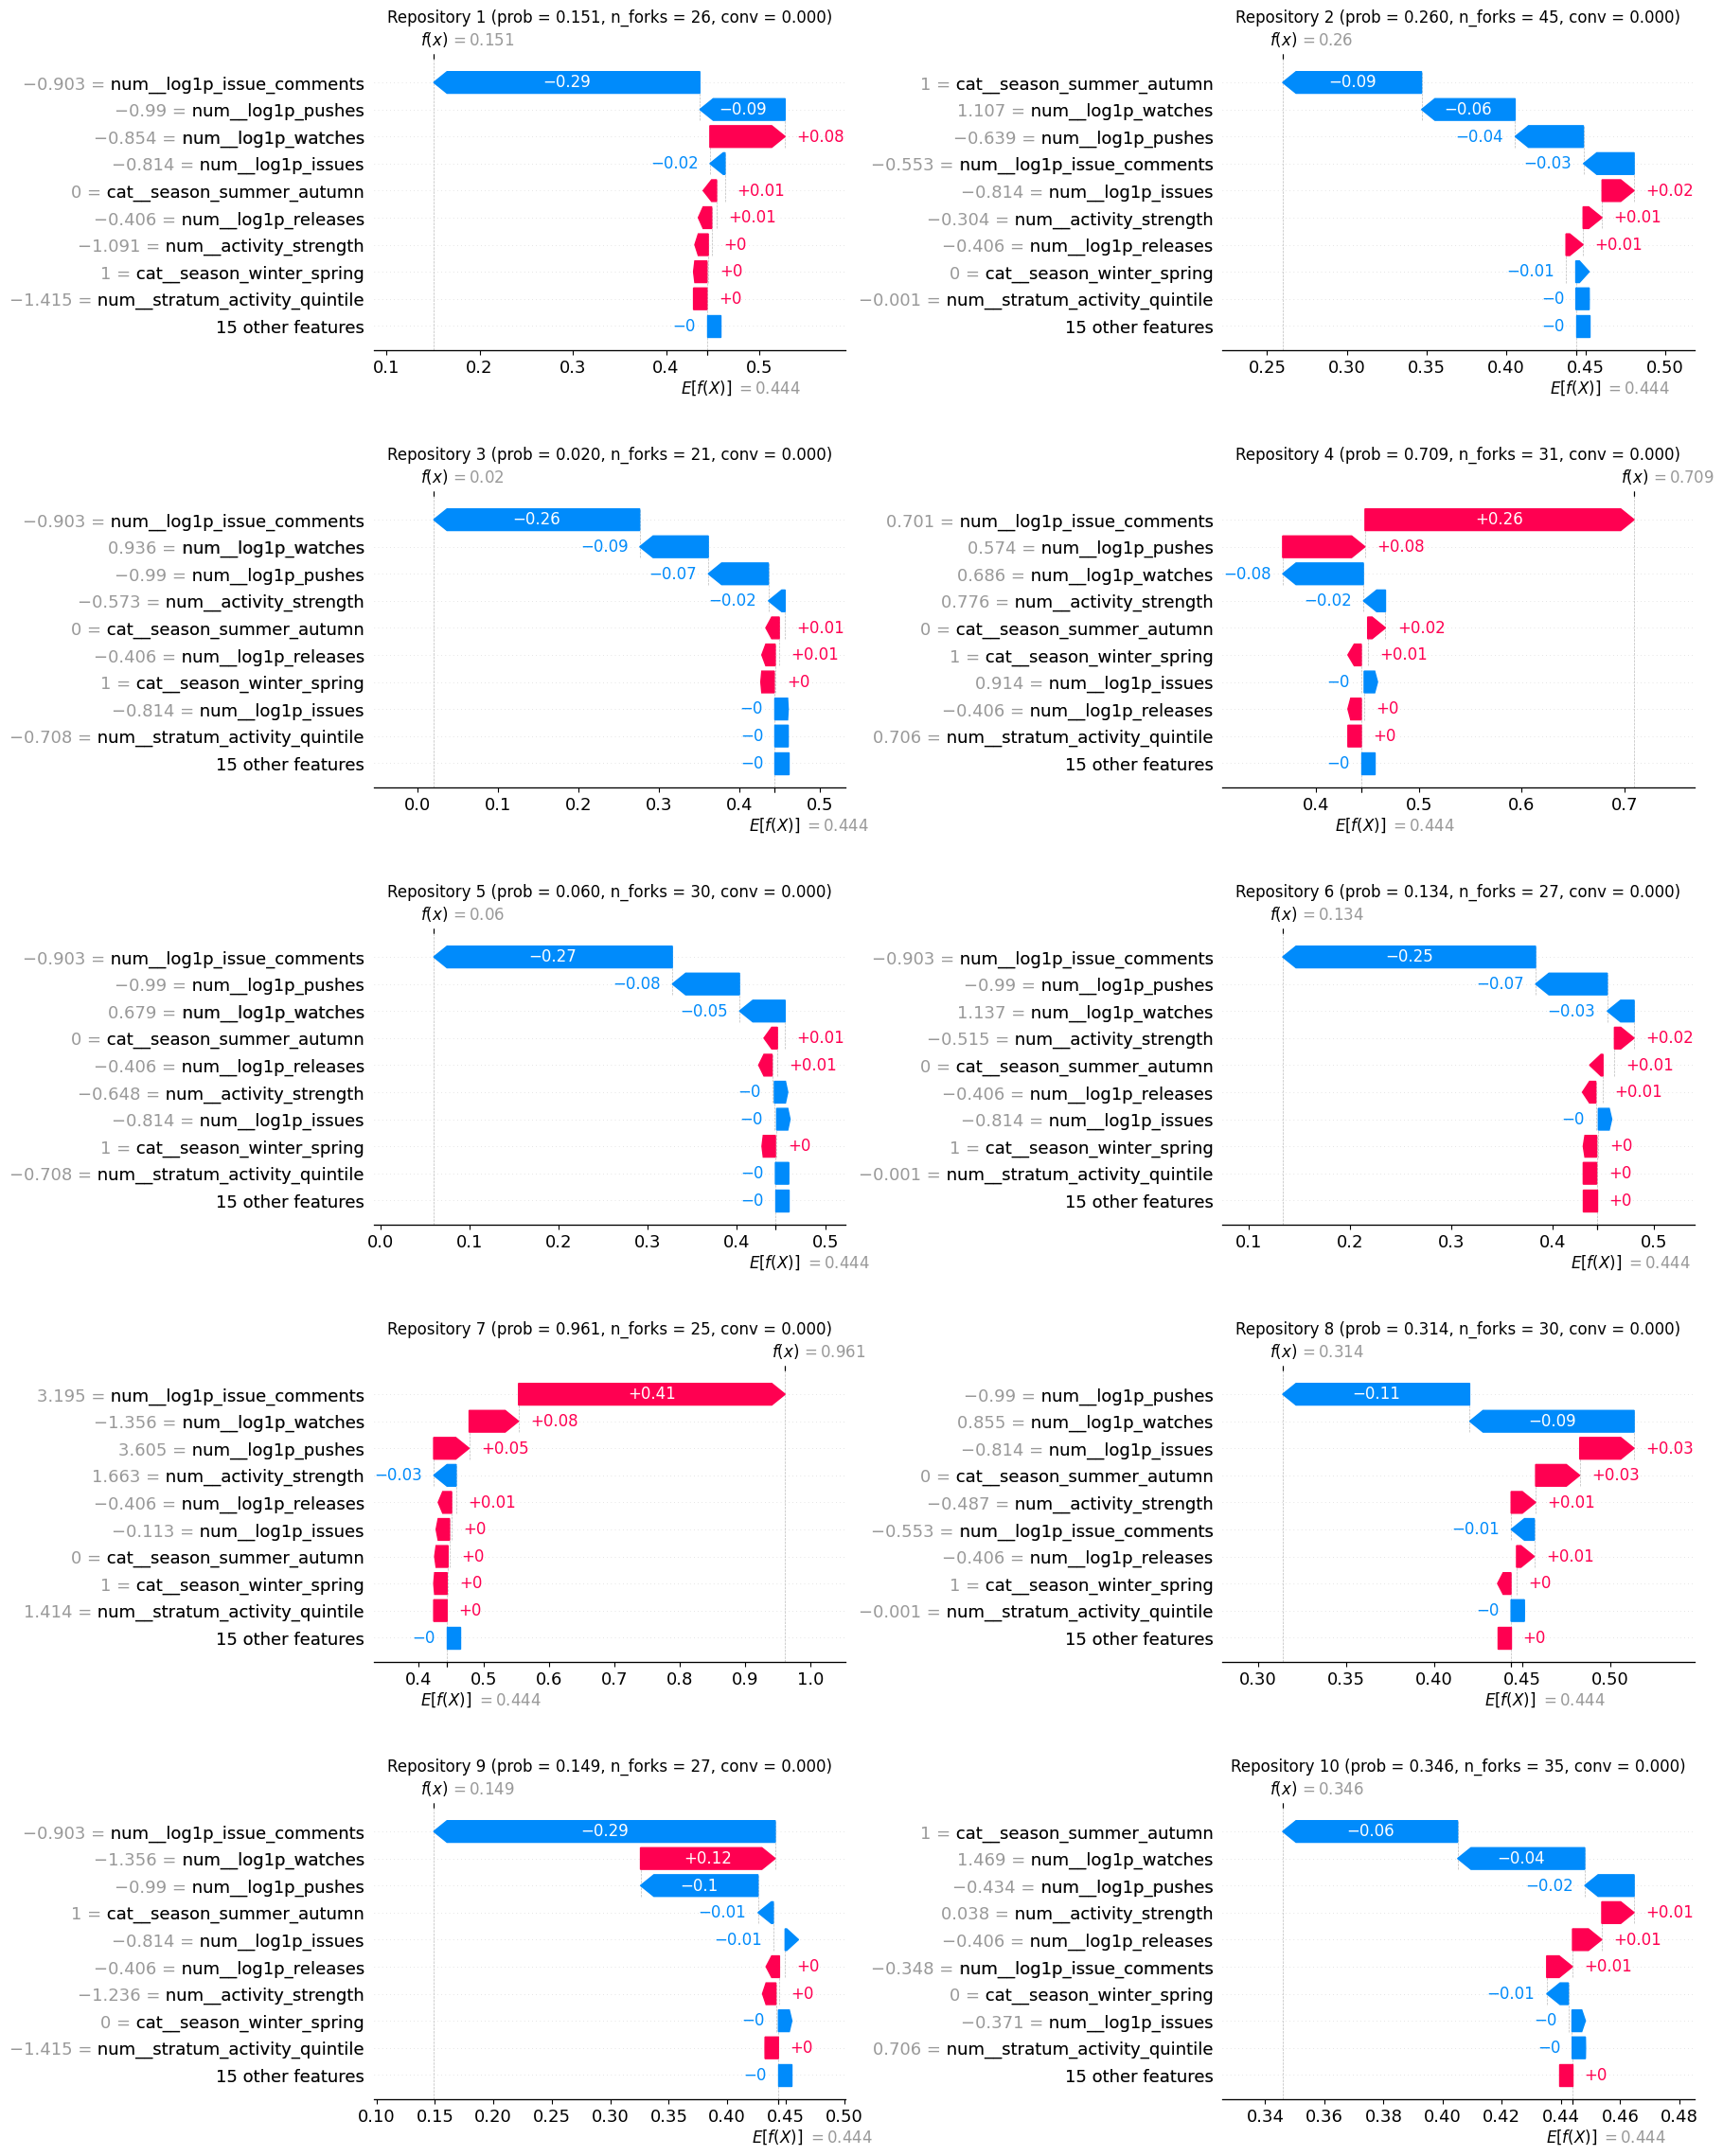

In [270]:
import matplotlib.pyplot as plt
import shap

# Create the grid (figsize will be overridden later)
fig, axes = plt.subplots(5, 2)
axes = axes.flatten()

for i, ax in enumerate(axes):
    exp = shap_values_segment[i, :, 1]          # Explanation for class 1
    prob = probs[i]
    n_forks = forks[i]
    conv = convs[i]
    plt.sca(ax)
    shap.plots.waterfall(exp, show=False)
    ax.set_title(f"Repository {i+1} (prob = {prob:.3f}, n_forks = {n_forks}, conv = {conv:.3f})")


# Adjust overall figure size and spacing
fig.set_size_inches(18, 28)                  # width, height
plt.subplots_adjust(hspace=0.5, wspace=0.8)  # vertical & horizontal gaps
# fig.savefig('shap_waterfall_cls.png', dpi=300, bbox_inches='tight')
plt.show()

### Estimation of segment size

Generally, let's compute the number of repositories with high-fork activity and low conversion:

In [274]:
# 1. Define thresholds (e.g., 75th percentile for forks, 25th for conversion)
high_fork_thresh = np.percentile(y_forks, 75)
low_conv_thresh = np.percentile(y_reg, 25)

# 2. Create boolean mask
high_fork = y_forks >= high_fork_thresh
low_conv = y_reg <= low_conv_thresh
segment_mask = high_fork & low_conv

# Get indices (original DataFrame index or integer positions)
segment_indices = np.where(segment_mask)[0]          # positions in array

# Retrieve full rows
data_segment = df.iloc[segment_indices]

print(f"High fork threshold: {high_fork_thresh}")
print(f"Low conversion threshold: {low_conv_thresh}")
print(f"Number of repositories in segment: {len(segment_indices)} ({round(100 * len(segment_indices) / len(fork_data), 2)}%)")

High fork threshold: 20.0
Low conversion threshold: 0.0
Number of repositories in segment: 9158 (9.16%)


Sample repositories:

In [278]:
print(data_segment[['repo_name', 'n_forks', 'n_converted_forks']].head(10))

                                             repo_name  n_forks  \
15             Complete-Coding/NodeJS_Complete_YouTube       30   
16                              typecraft-dev/dotfiles       21   
39                                   lilishop/lilishop       27   
54                         asedyrudi8/fake-usdt-sender       92   
69   APCSA-Turin/jr-apcsa-turin-56-u7p1_poker_simpl...       27   
80                            saikiranpi/mastering-aws       55   
83                               Tarayyy/ase-practice2       45   
97                                AshokShau/TgMusicBot       28   
98                     tmwarniatbio/hack-crypto-wallet       20   
100                                  vxcontrol/pentagi       25   

     n_converted_forks  
15                   0  
16                   0  
39                   0  
54                   0  
69                   0  
80                   0  
83                   0  
97                   0  
98                   0  
100         

Repositories from this segment seem to be educational projects or project configurations. Overall, high fork activity alone does not signal a healthy and contribution-ready community.